<a href="https://colab.research.google.com/github/chungwa-Hani/CodeAlpha_Iris_Classification/blob/main/iris_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Project Overview

This project focuses on classifying Iris flowers into three different species: *Iris-setosa*, *Iris-versicolor*, and *Iris-virginica*.

The classification will be based on measurements of the flowers, including sepal length, sepal width, petal length, and petal width.

The project follows a typical machine learning workflow, beginning with data exploration and preparation, followed by exploratory data analysis, model development, prediction, and evaluation.


## 2. Problem Statement

The objective of this project is to develop a classification model that can accurately identify the species of an Iris flower based on its measured characteristics.

The model will use the available flower measurements as input features and predict one of three species:

* *Iris-setosa*
* *Iris-versicolor*
* *Iris-virginica*


## 3. Project Objectives

The main objectives of this project are to:

1. Load and inspect the Iris dataset.
2. Understand the structure and characteristics of the data.
3. Identify and address any data-quality issues.
4. Perform exploratory data analysis (EDA).
5. Visualize relationships between the flower measurements and species.
6. Prepare the data for machine learning.
7. Split the dataset into training and testing sets.
8. Train a classification model.
9. Make predictions on unseen test data.
10. Evaluate the performance of the classification model.
11. Interpret the results and draw conclusions.


## 4. Dataset Description

The Iris dataset contains measurements of Iris flowers belonging to three different species.

The main measurement variables are:

| Feature      | Description         |
| ------------ | ------------------- |
| Sepal Length | Length of the sepal |
| Sepal Width  | Width of the sepal  |
| Petal Length | Length of the petal |
| Petal Width  | Width of the petal  |

The target variable is the Iris flower species.

The dataset also contains an `Id` column that identifies individual records.


## 5. Importing required libraries

In [7]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## 6. Loading the Dataset

In [8]:
# Loading the iris dataset
df = pd.read_csv("/content/Iris.csv")

In [9]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 7. Initial Data Inspection

Before cleaning or analysing the dataset, it is important to inspect its structure and contents.

The initial inspection will help us determine:

* The number of observations and variables.
* The data types of each variable.
* Whether missing values are present.
* Whether duplicate records exist.
* The statistical characteristics of the numerical features.
* The number of observations belonging to each Iris species.

These checks will help identify any data-quality issues that need to be addressed before model development.


In [10]:
# checking the shape of the Dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 150
Number of columns: 6


In [11]:
# Checking column names

print("Column names:")
for column in df.columns:
    print("--->", column)

Column names:
---> Id
---> SepalLengthCm
---> SepalWidthCm
---> PetalLengthCm
---> PetalWidthCm
---> Species


In [12]:
#checking the data type

print("Data types:")
print(df.dtypes)

Data types:
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object


In [13]:
# Checking Missing values

print("Missing values:")
df.isnull().sum()

Missing values:


,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [14]:
#checking Duplicates

print("Duplicates: ", df.duplicated().sum())

Duplicates:  0


In [15]:
# Checking the number of different species

print("Number of observations per species:")
print(df["Species"].value_counts())

Number of observations per species:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [16]:
# Summary Statistics

print("Summary statistics:")
df.describe()

Summary statistics:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## 8. Data Cleaning and Preparation

Before developing the classification model, the dataset needs to be checked and prepared to ensure that the variables are suitable for analysis and machine learning.

The initial inspection showed that the dataset contains no missing values and no duplicate records. Therefore, no missing-value imputation or duplicate removal is required.

The `Id` column will also be excluded from the predictive features because it is an identifier for each observation and does not represent a measurable characteristic of the flower.

The four flower measurements will be retained as the input features, while `Species` will be used as the target variable.


In [17]:
# Selecting the input features
X = df[[
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]]

# Selecting the target variable
y = df["Species"]

print("Number of features:", X.shape[1])
print("Number of observations:", X.shape[0])
print("Target variable:", y.name)

Number of features: 4
Number of observations: 150
Target variable: Species


In [18]:
# Verify Features

print("Features used for classification:")
for column in X.columns:
    print("--->", column)

Features used for classification:
---> SepalLengthCm
---> SepalWidthCm
---> PetalLengthCm
---> PetalWidthCm


In [20]:
# Verify Target

print("Target classes:")
print(y.unique())

Target classes:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


### 8.1 Data Preparation Findings

The dataset is suitable for further analysis because no missing values or duplicate records were identified during the initial inspection.

Four flower measurements were selected as input features:

* Sepal length
* Sepal width
* Petal length
* Petal width

The `Species` column was selected as the target variable because it represents the species that the classification model will predict.

The `Id` column was excluded because it serves only as an identifier and does not describe a measurable characteristic of the flower.

The prepared dataset therefore contains **four input features and one target variable**.


## 9. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is used to understand the patterns, distributions, and relationships within the dataset before developing a machine learning model.

In this section, the distribution of the Iris species will first be examined. The numerical features will then be visualized to understand their distributions and to identify differences between the three species.

The analysis will also investigate relationships between the flower measurements to determine whether some features show clear patterns associated with different Iris species.


### 9.1 Species Distribution

The distribution of the target classes will be visualized to determine whether the dataset is balanced across the three Iris species.


Number of observations per species:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


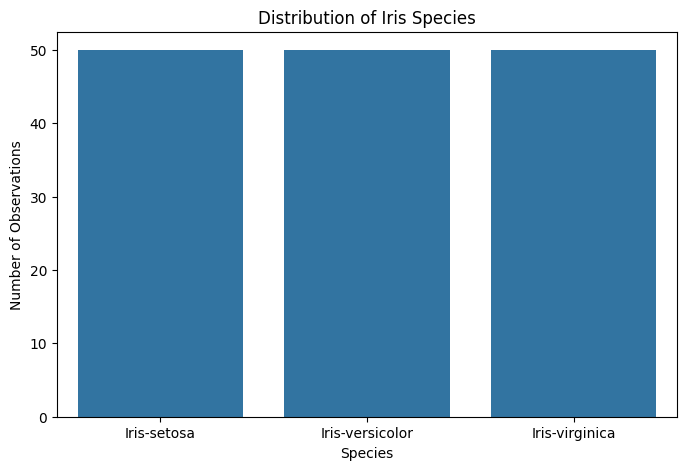

In [21]:
# Count the observations for each species
species_counts = df["Species"].value_counts()

print("Number of observations per species:")
print(species_counts)

# Create a bar chart
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Species")

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Number of Observations")
plt.show()

### 9.2 Feature Distributions

The next step is to examine the distributions of the four numerical features used for classification.

Histograms will be used to visualize the values of sepal length, sepal width, petal length, and petal width. These visualizations help identify the range and distribution of each measurement and provide an initial understanding of how the features vary across the dataset.


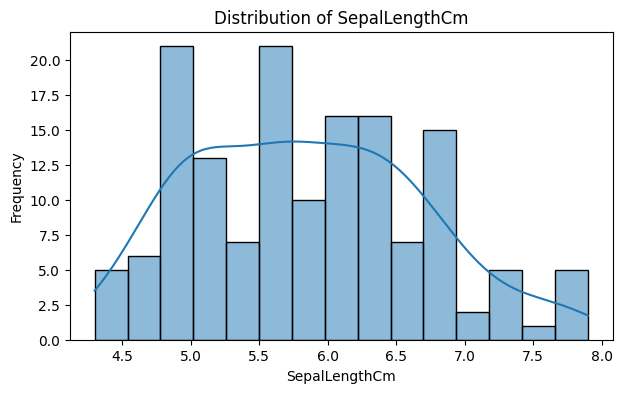

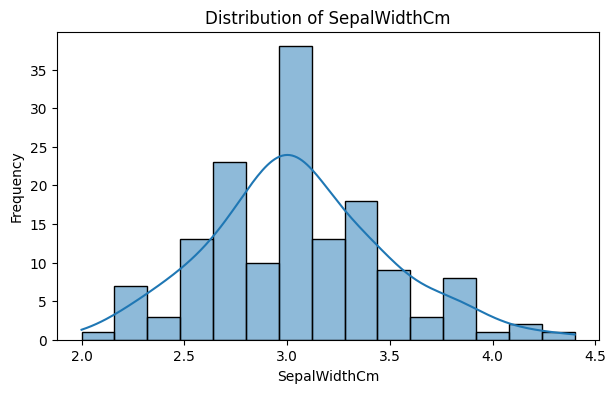

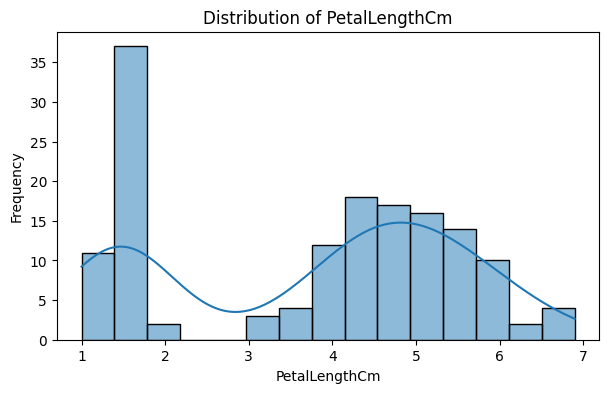

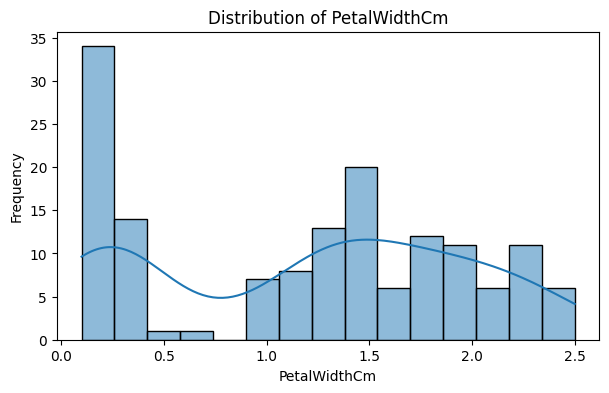

In [22]:
# Features selected for analysis
features = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

# Plot the distribution of each feature
for feature in features:
    plt.figure(figsize=(7, 4))

    sns.histplot(data=df, x=feature, bins=15, kde=True)

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()